In [121]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec as gs

engine = create_engine(
    "postgresql+psycopg2://postgres@localhost:5432/abc_xyz"
)

df = pd.read_sql(
    "SELECT current_database();",
    engine
)
print(df)

  current_database
0          abc_xyz


In [122]:
abc_xyz_analysis_pizza = pd.read_sql(
    """select
    *
from abc_xyz_analysis_pizza
order by revenue desc, quantity desc""",
    engine)

display(abc_xyz_analysis_pizza)

,name,ingredients,revenue,quantity,abc_revenue_quantity,xyz_category,abc_xyz_rev_quant_cv
0,The Thai Chicken Pizza,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",43434.25,2371,AA,X,AAX
1,The Barbecue Chicken Pizza,"Barbecued Chicken, Red Peppers, Green Peppers,...",42768.00,2432,AA,X,AAX
2,The California Chicken Pizza,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ...",41409.50,2370,AA,X,AAX
3,The Classic Deluxe Pizza,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",38180.50,2453,AA,X,AAX
4,The Spicy Italian Pizza,"Capocollo, Tomatoes, Goat Cheese, Artichokes, ...",34831.25,1924,AA,Y,AAY
5,The Southwest Chicken Pizza,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja...",34705.75,1917,AA,X,AAX
6,The Italian Supreme Pizza,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",33476.75,1884,AA,X,AAX
7,The Hawaiian Pizza,"Sliced Ham, Pineapple, Mozzarella Cheese",32273.25,2422,AA,X,AAX
8,The Four Cheese Pizza,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",32265.70,1902,AA,X,AAX
9,The Sicilian Pizza,"Coarse Sicilian Salami, Tomatoes, Green Olives...",30940.50,1938,AA,X,AAX


In [123]:
pizza_sales = pd.read_sql(
    """select
    *
from pizza_sales
order by order_id
limit 5""",
    engine)

display(pizza_sales)

,order_id,full_date,name,size,category,price,quantity,revenue,ingredients
0,1,2015-01-01 11:38:36,The Hawaiian Pizza,M,Classic,13.25,1,13.25,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2015-01-01 11:57:40,The Classic Deluxe Pizza,M,Classic,16.00,1,16.00,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,2015-01-01 11:57:40,The Italian Supreme Pizza,L,Supreme,20.75,1,20.75,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
3,2,2015-01-01 11:57:40,The Five Cheese Pizza,L,Veggie,18.50,1,18.50,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
4,2,2015-01-01 11:57:40,The Mexicana Pizza,M,Veggie,16.00,1,16.00,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [ ]:
abc_xyz_analysis_pizza = pd.read_sql(
    """select
    *
from abc_xyz_analysis_pizza
order by revenue desc, quantity desc
limit 5""",
    engine)

display(abc_xyz_analysis_pizza)

,name,ingredients,revenue,quantity,abc_revenue_quantity,xyz_category,abc_xyz_rev_quant_cv
0,The Thai Chicken Pizza,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",43434.25,2371,AA,X,AAX
1,The Barbecue Chicken Pizza,"Barbecued Chicken, Red Peppers, Green Peppers,...",42768.00,2432,AA,X,AAX
2,The California Chicken Pizza,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ...",41409.50,2370,AA,X,AAX
3,The Classic Deluxe Pizza,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",38180.50,2453,AA,X,AAX
4,The Spicy Italian Pizza,"Capocollo, Tomatoes, Goat Cheese, Artichokes, ...",34831.25,1924,AA,Y,AAY


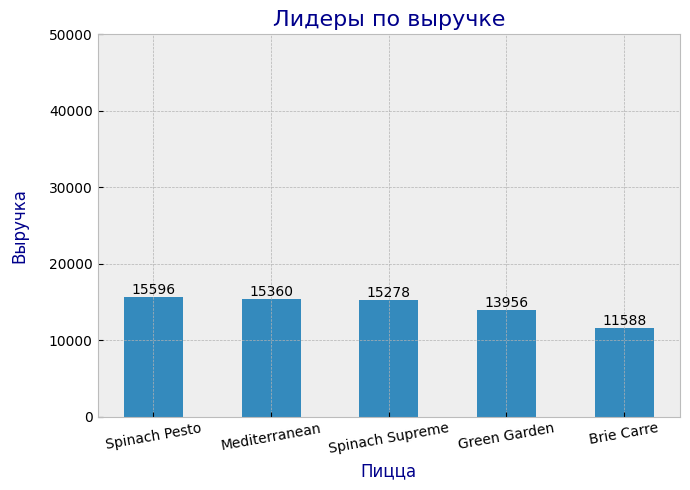

In [180]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.style.use('bmh')

bars = ax.bar(abc_xyz_analysis_pizza['name'].str.replace('The ', '', regex=False).str.replace(' Pizza', '', regex=False), 
        abc_xyz_analysis_pizza['revenue'],
        width = 0.5)

ax.set_title("Лидеры по выручке", color = 'darkblue', fontsize = 16)
ax.set_xlabel("Пицца", color = 'darkblue')
ax.set_ylabel("Выручка", labelpad = 15, color = 'darkblue')
ax.tick_params(axis = 'x', rotation = 10, labelsize = 10)
ax.set_ylim(0, 50000)

plt.bar_label(
    bars,
    fmt='%.0f')

plt.tight_layout()

In [182]:
abc_xyz_analysis_pizza = pd.read_sql(
    """select *
from (
    select *
    from abc_xyz_analysis_pizza
    order by revenue asc, quantity asc
    limit 5
)
order by revenue desc
""",
    engine)

print(abc_xyz_analysis_pizza.to_markdown())

|    | name                      | ingredients                                                                                      |   revenue |   quantity | abc_revenue_quantity   | xyz_category   | abc_xyz_rev_quant_cv   |
|---:|:--------------------------|:-------------------------------------------------------------------------------------------------|----------:|-----------:|:-----------------------|:---------------|:-----------------------|
|  0 | The Spinach Pesto Pizza   | Spinach, Artichokes, Tomatoes, Sun-dried Tomatoes, Garlic, Pesto Sauce                           |   15596   |        970 | BB                     | Z              | BBZ                    |
|  1 | The Mediterranean Pizza   | Spinach, Artichokes, Kalamata Olives, Sun-dried Tomatoes, Feta Cheese, Plum Tomatoes, Red Onions |   15360.5 |        934 | CC                     | Y              | CCY                    |
|  2 | The Spinach Supreme Pizza | Spinach, Red Onions, Pepperoni, Tomatoes, Artichokes, Kalamat

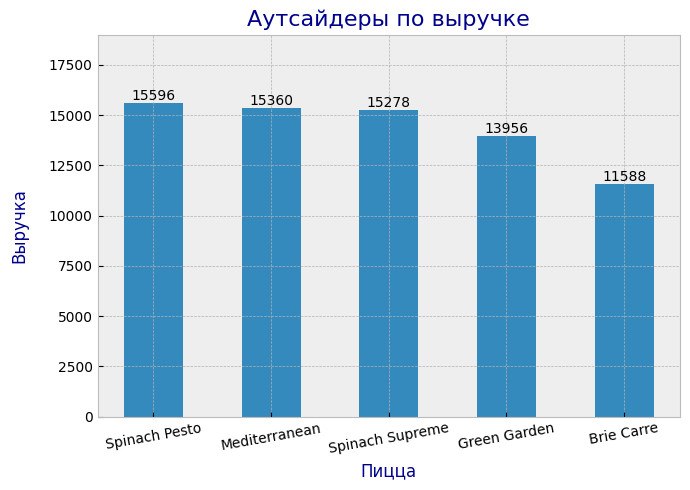

In [181]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.style.use('bmh')

bars = ax.bar(abc_xyz_analysis_pizza['name'].str.replace('The ', '', regex=False).str.replace(' Pizza', '', regex=False), 
        abc_xyz_analysis_pizza['revenue'],
        width = 0.5)

ax.set_title("Аутсайдеры по выручке", color = 'darkblue', fontsize = 16)
ax.set_xlabel("Пицца", color = 'darkblue')
ax.set_ylabel("Выручка", labelpad = 15, color = 'darkblue')
ax.tick_params(axis = 'x', rotation = 10, labelsize = 10)
ax.set_ylim(0, 19000)

plt.bar_label(
    bars,
    fmt='%.0f')

plt.tight_layout()